<a href="https://colab.research.google.com/github/bigmackfridayfun789/CSCE1015/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

*   List item
*   List item



In [11]:
#Please write the code here
import pandas as pd
import numpy as np
from google.colab import files
uploaded = files.upload()

# Load the dataset
df = pd.read_csv("car_purchase_data.csv")
df = df[['Age', 'Salary', 'Purchased']]

# Preview the first few rows
df.head()


Saving car_purchase_data.csv to car_purchase_data (1).csv


,Age,Salary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


### Step 2: Split features and target

In [12]:
#Please write the code here


# Features: Age, Salary
X = df[['Age', 'Salary']]
y = df['Purchased']


### Step 3: Train/Test Split

In [51]:
#Please write the code here
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Step 4: Feature Scaling

In [15]:
#Please write the code here
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




### Step 5: Train Logistic Regression Model

In [16]:
#Please write the code here
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

# Train the model
log_reg.fit(X_train_scaled, y_train)


LogisticRegression()

### Step 6: Predict and Evaluate

In [52]:
#Please write the code here
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


y_pred = log_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

accuracy, conf_matrix, class_report


(0.8625,
 array([[50,  2],
        [ 9, 19]]),
 '              precision    recall  f1-score   support\n\n           0       0.85      0.96      0.90        52\n           1       0.90      0.68      0.78        28\n\n    accuracy                           0.86        80\n   macro avg       0.88      0.82      0.84        80\nweighted avg       0.87      0.86      0.86        80\n')

### Step 7: Visualization of Decision Regions

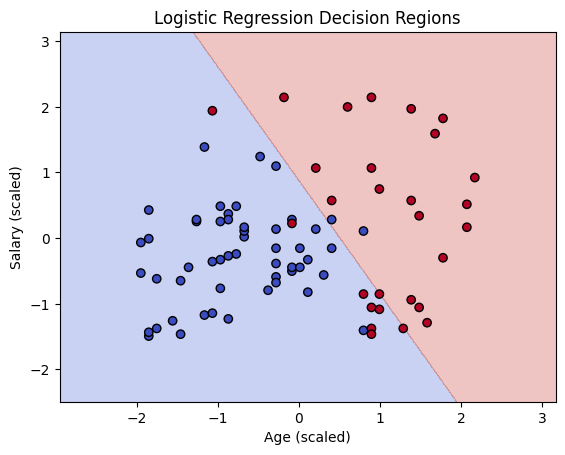

In [18]:
#Please write the code here
import numpy as np
import matplotlib.pyplot as plt

X_set, y_set = X_test_scaled, y_test.values

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

Z = log_reg.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap='coolwarm', edgecolors='k')

plt.title("Logistic Regression Decision Regions")
plt.xlabel("Age (scaled)")
plt.ylabel("Salary (scaled)")
plt.show()



## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. Logistic regression models the probability that an observation belongs to the positive class. Even though the output is a probability between 0 and 1, we can convert that probability into a class label by applying a threshold (commonly 0.5). If the predicted probability is ≥ 0.5, we classify it as 1; otherwise, we classify it as 0. This makes logistic regression both a probabilistic model and a classification algorithm.
2. From the model’s decision boundary and coefficients, customers with higher salaries and higher ages tend to have a higher probability of purchasing a car. In other words, older individuals with greater income levels fall into the region where the model predicts “Purchased = 1.” Younger customers with lower salaries are more likely to be predicted as non‑purchasers.
3. Limited features: The dataset only includes Age and Salary, which may not fully explain purchasing behavior. Class imbalance: If one class appears more often, the model may struggle with the minority class. Overlapping data: Some customers with similar Age/Salary values may behave differently, making the classes hard to separate. Small dataset size: With fewer samples, the model has less information to learn clear patterns.
4. Some features that that could help assist in improving the accuracy are adding additional features: Credit score, marital status, number of dependents, car ownership history, or geographic region. and outlier handling: Removing extreme salary values that distort the model.
